# Siamese few-shot learning: synthetic verification

This compact notebook verifies the repository's training and episodic-evaluation workflow without downloading MiniImageNet. The generated stripe patterns are deliberately simple; their scores are **not research benchmarks**.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from siamese_fewshot import (
    CompactEncoder, ContrastiveLoss, PairDataset, PatternDataset,
    SiameseNetwork, evaluate_episodes, seed_everything, train_contrastive_epoch,
)

## Generated classes
Each class combines a stripe orientation, frequency, and colour channel. Noise creates multiple examples without copying any external images.

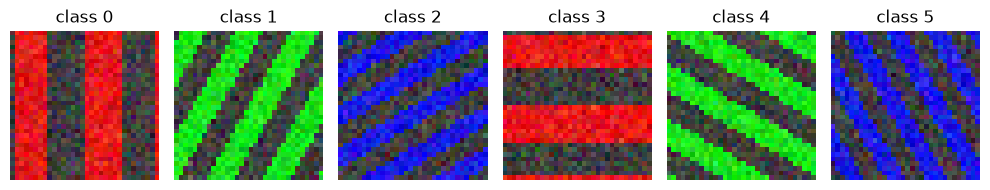

In [2]:
generator = seed_everything(42, deterministic=True)
dataset = PatternDataset(class_count=6, samples_per_class=18, seed=42)
pairs = PairDataset(dataset, length=384, seed=42)
loader = DataLoader(pairs, batch_size=48, shuffle=True, generator=generator)

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for label, axis in enumerate(axes):
    image, _ = dataset[label * 18]
    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(f'class {label}')
    axis.axis('off')
plt.tight_layout()

## Shared encoder and contrastive training
A positive pair is pulled together in embedding space; a negative pair is penalized when its distance is below the margin.

In [3]:
model = SiameseNetwork(CompactEncoder(embedding_dim=32, base_channels=8))
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
criterion = ContrastiveLoss(margin=1.0)
losses = [train_contrastive_epoch(model, loader, optimizer, criterion) for _ in range(5)]
losses

[0.035968993906863034,
 0.005790347437141463,
 0.004660728067392483,
 0.0027436664095148444,
 0.0026770992699312046]

## Episodic evaluation
Support and query examples are disjoint inside every episode. Accuracy is averaged over 30 independently sampled 5-way episodes, with a normal-approximation 95% confidence interval.

In [4]:
one_shot = evaluate_episodes(model, dataset, n_way=5, k_shot=1, queries_per_class=2, episodes=30, seed=100)
four_shot = evaluate_episodes(model, dataset, n_way=5, k_shot=4, queries_per_class=2, episodes=30, seed=200)
{
    '1-shot mean accuracy': round(one_shot.mean_accuracy, 3),
    '1-shot 95% CI': round(one_shot.confidence_interval_95, 3),
    '4-shot mean accuracy': round(four_shot.mean_accuracy, 3),
    '4-shot 95% CI': round(four_shot.confidence_interval_95, 3),
}

{'1-shot mean accuracy': 1.0,
 '1-shot 95% CI': 0.0,
 '4-shot mean accuracy': 1.0,
 '4-shot 95% CI': 0.0}

## Interpretation boundary
This run checks tensor shapes, optimization, support/query separation, and metric reporting. It does not reproduce the archived MiniImageNet results and must not be cited as model performance on real images.